In [6]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [7]:
dataset = pd.read_csv("pricerunner_aggregate.csv")
dataset.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [8]:
print(dataset.columns.tolist())

['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label', ' Category ID', ' Category Label']


In [9]:
dataset = dataset.drop(' Category Label', axis = 1)

In [10]:
dataset = dataset.drop('Product Title', axis = 1)

In [11]:
dataset = dataset.drop('Product ID', axis = 1)

In [12]:
dataset = dataset.drop(' Cluster Label', axis = 1)

In [13]:
dataset

,Merchant ID,Cluster ID,Category ID
0,1,1,2612
1,2,1,2612
2,3,1,2612
3,4,1,2612
4,5,1,2612
...,...,...,...
35306,59,47517,2623
35307,59,47518,2623
35308,59,47519,2623
35309,125,47524,2623


In [14]:
dataset[' Category ID'] = pd.factorize(dataset[' Category ID'])[0]

In [15]:
dataset

,Merchant ID,Cluster ID,Category ID
0,1,1,0
1,2,1,0
2,3,1,0
3,4,1,0
4,5,1,0
...,...,...,...
35306,59,47517,9
35307,59,47518,9
35308,59,47519,9
35309,125,47524,9


In [16]:
vals = dataset[" Category ID"].unique()
vals

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

данных слишком много, коллаб не вывозит

In [17]:
from sklearn.model_selection import train_test_split

# Например, берем 10% данных с сохранением пропорций классов
dataset_small, _ = train_test_split(
    dataset,
    test_size=0.9,  # 90% отбрасываем, 10% оставляем
    stratify=dataset[' Category ID'],  # или твой целевой столбец с классами
    random_state=42
)

In [26]:
# сохраняем только числовые столбцы. Целевую переменную убираем
cols_for_clusters = [' Merchant ID',' Cluster ID']

df = dataset_small[cols_for_clusters].copy() # делаем копию, чтобы не было сюрпризов с исходным набором данных

In [19]:
df.head()

,Merchant ID,Cluster ID
3609,48,1384
10184,66,6715
6191,18,4770
33960,300,46629
26985,119,44124


In [28]:
X = df
y = dataset_small[" Category ID"].replace(vals, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
yvals = dataset[" Category ID"]

данные готовы, перейдем к алгоритмам

данных слишком много, поэтому разделим их

In [29]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

k_means_8: X shape = 3531, labels shape = 3531
k_means_3: X shape = 3531, labels shape = 3531
k_means_bad_init: X shape = 3531, labels shape = 3531


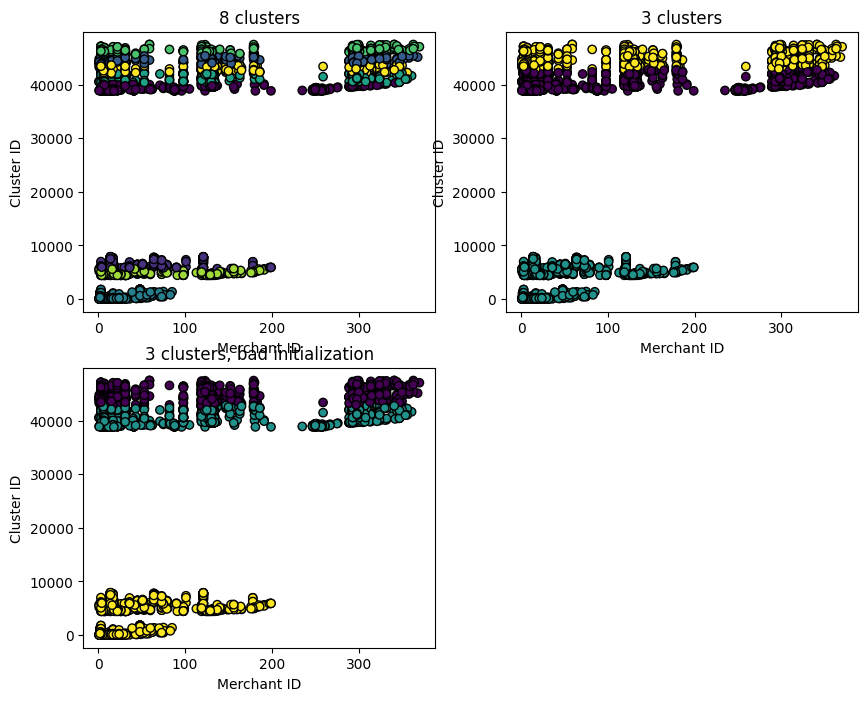

In [30]:
estimators = [
    ("k_means_8", KMeans(n_clusters=8)),
    ("k_means_3", KMeans(n_clusters=3)),
    ("k_means_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]

for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1)

    # Обучаем модель
    est.fit(X)
    labels = est.labels_

    # Убеждаемся, что размерности совпадают
    print(f"{name}: X shape = {X.shape[0]}, labels shape = {len(labels)}")

    # Если всё совпадает, строим график
    if X.shape[0] == len(labels):
        ax.scatter(X[" Merchant ID"], X[" Cluster ID"], c=labels, cmap='viridis', edgecolor="k")
    else:
        print(f"Ошибка размерностей для {name}!")

    ax.set_xlabel("Merchant ID")
    ax.set_ylabel("Cluster ID")
    ax.set_title(title)

он определенно что-то поделил, но данных много, что они слились в кашу
ну сейчас получше, данных поменьше

метрики

In [31]:
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score


n_clusters = np.arange(2, 21)

In [32]:
best_metric = [0, -1, -1, []]

silhouette_score_values = []
adjusted_rand_score_values = []

for n in n_clusters:
    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10, random_state=42)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)

    # Обновляем лучший результат
    if score1 > best_metric[1]:  # силуэт: чем БОЛЬШЕ, тем лучше
        best_metric[1] = score1
        best_metric[2] = score2
        best_metric[3] = clusterer.cluster_centers_
        best_metric[0] = n
        print(f"Новый лучший силуэт: {score1:.4f} для n={n} (ARI: {score2:.4f})")

Новый лучший силуэт: 0.9252 для n=2 (ARI: 0.1710)


In [33]:
best_metric

[np.int64(2),
 np.float64(0.9251956171519128),
 0.170973246006187,
 array([[  158.61806723, 42794.43193277],
        [   45.16854909,  3879.51867941]])]

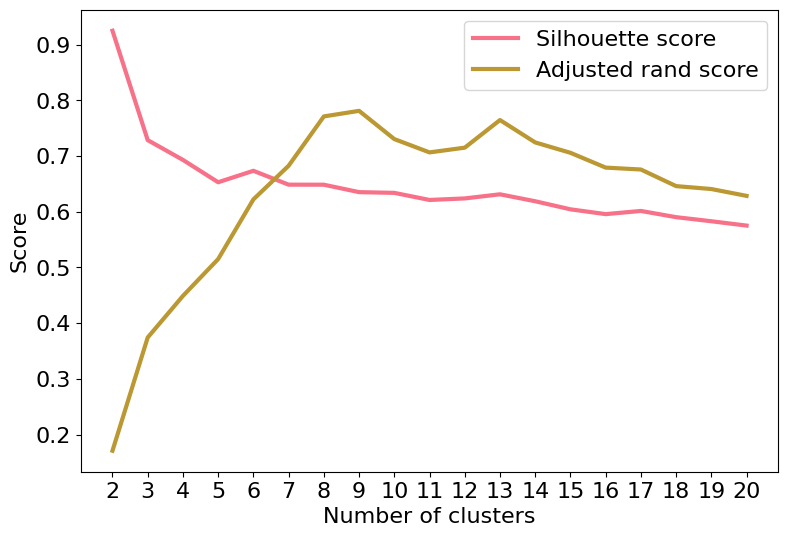

In [34]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Adjusted rand score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()

на график из методички не особо похоже, признаки не дают информацию о категории

иерархическая кластеризация

In [35]:
from scipy.cluster.hierarchy import linkage, dendrogram

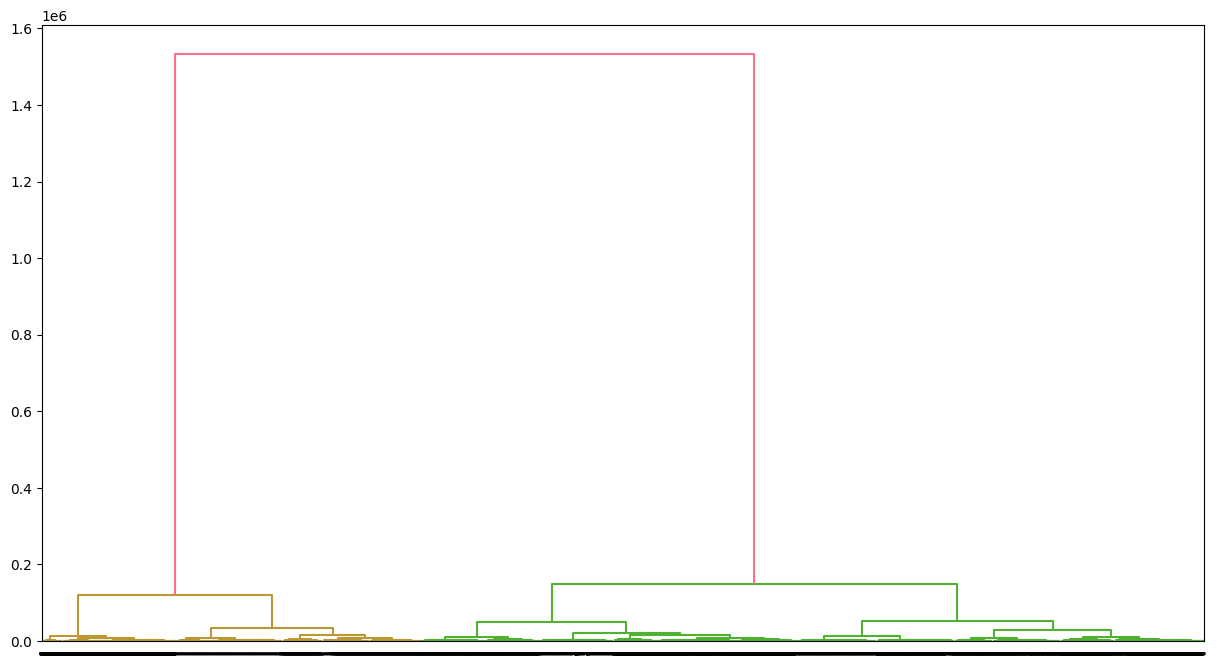

In [36]:
samples = df.values

# Реализация иерархической кластеризации при помощи функции linkage
mergings = linkage(samples, method='ward')

plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           labels=list(y),
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

сплющило

In [37]:
#реальные данные
samples_real = df.values
mergings_real = linkage(samples_real, method='ward')

#случайные данные того же размера
samples_random = np.random.randn(*samples_real.shape)
mergings_random = linkage(samples_random, method='ward')

#сравним расстояния слияния
print("Реальные данные - последние 5 расстояний:", mergings_real[-5:, 2])
print("Случайные данные - последние 5 расстояний:", mergings_random[-5:, 2])

Реальные данные - последние 5 расстояний: [  50175.13060595   52688.7792141   120315.60698609  148803.81651297
 1532887.17834071]
Случайные данные - последние 5 расстояний: [25.28618611 32.94041726 37.37974167 49.53748962 64.88987665]


такие большие расстояния - это странно

In [39]:
print("Мин и макс Merchant ID:", X[" Merchant ID"].min(), X[" Merchant ID"].max())
print("Мин и макс Cluster ID:", X[" Cluster ID"].min(), X[" Cluster ID"].max())

Мин и макс Merchant ID: 1 370
Мин и макс Cluster ID: 1 47518


нормализуем данные и переделаем кластеризацию

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Нормализуем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[[" Merchant ID", " Cluster ID"]])

# Очищаем списки
silhouette_score_values = []
adjusted_rand_score_values = []
n_clusters_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]  # явный список

for n in n_clusters_list:
    print(f"n={n}", end=" ")

    clusterer = KMeans(n_clusters=n, random_state=42, n_init='auto')
    clusterer.fit(X_scaled)
    y_pred = clusterer.labels_

    score1 = metrics.silhouette_score(X_scaled, y_pred)
    score2 = metrics.adjusted_rand_score(y, y_pred)

    silhouette_score_values.append(score1)
    adjusted_rand_score_values.append(score2)

    print(f"Silhouette={score1:.4f}, ARI={score2:.4f}")

n=2 Silhouette=0.5245, ARI=0.0332
n=3 Silhouette=0.7541, ARI=0.1932
n=4 Silhouette=0.7708, ARI=0.2114
n=5 Silhouette=0.7073, ARI=0.1930
n=6 Silhouette=0.5907, ARI=0.2293
n=7 Silhouette=0.5721, ARI=0.1996
n=8 Silhouette=0.6237, ARI=0.1980
n=9 Silhouette=0.5089, ARI=0.2442
n=10 Silhouette=0.4387, ARI=0.2891


график

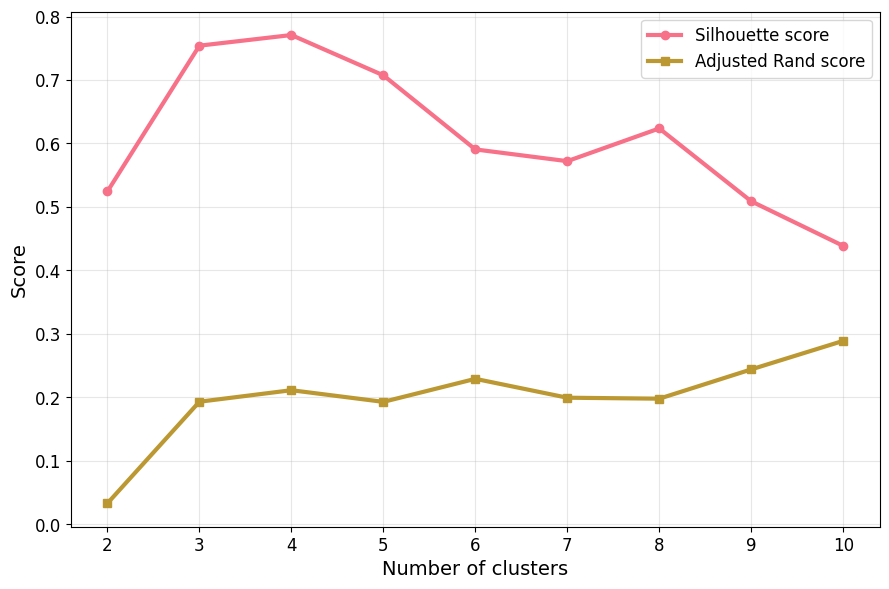

In [60]:
plt.figure(figsize=(9, 6))
plt.plot(list(n_clusters), silhouette_score_values, linewidth=3, marker='o', label='Silhouette score')
plt.plot(list(n_clusters), adjusted_rand_score_values, linewidth=3, marker='s', label='Adjusted Rand score')
plt.xlabel('Number of clusters', size=14)
plt.ylabel('Score', size=14)
plt.xticks(list(n_clusters), size=12)
plt.yticks(size=12)
plt.grid(alpha=0.3)
plt.legend(loc='best', fontsize=12)
plt.tight_layout()
plt.show()

стало получше

переделаем иерархическую

n=2: Silhouette=0.6082, ARI=0.1710
n=3: Silhouette=0.7544, ARI=0.1933
n=4: Silhouette=0.7708, ARI=0.2114
n=5: Silhouette=0.7231, ARI=0.1968
n=6: Silhouette=0.6867, ARI=0.1594
n=7: Silhouette=0.6183, ARI=0.1738
n=8: Silhouette=0.6144, ARI=0.1740
n=9: Silhouette=0.6311, ARI=0.1971
n=10: Silhouette=0.5971, ARI=0.1975


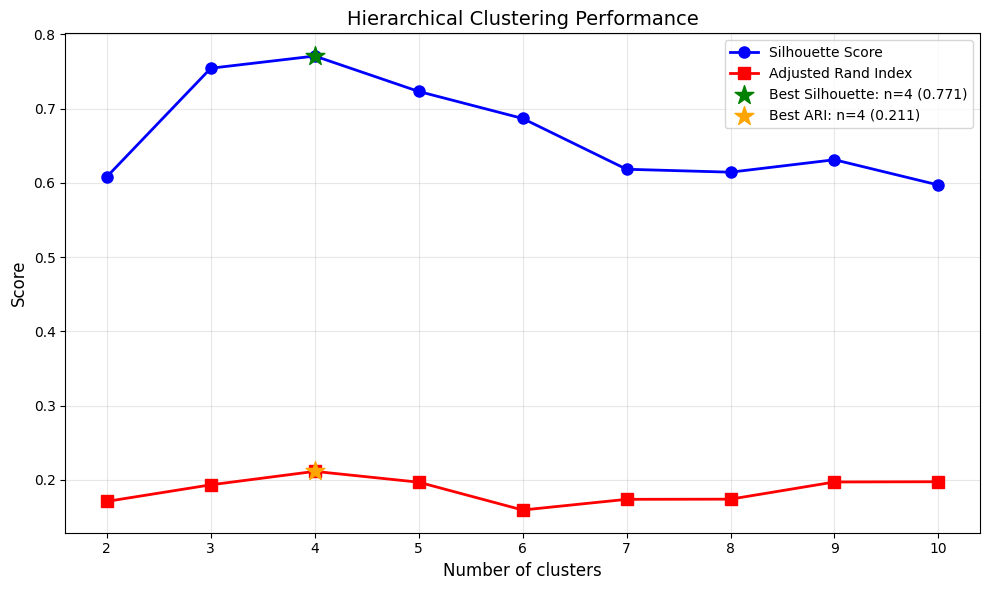

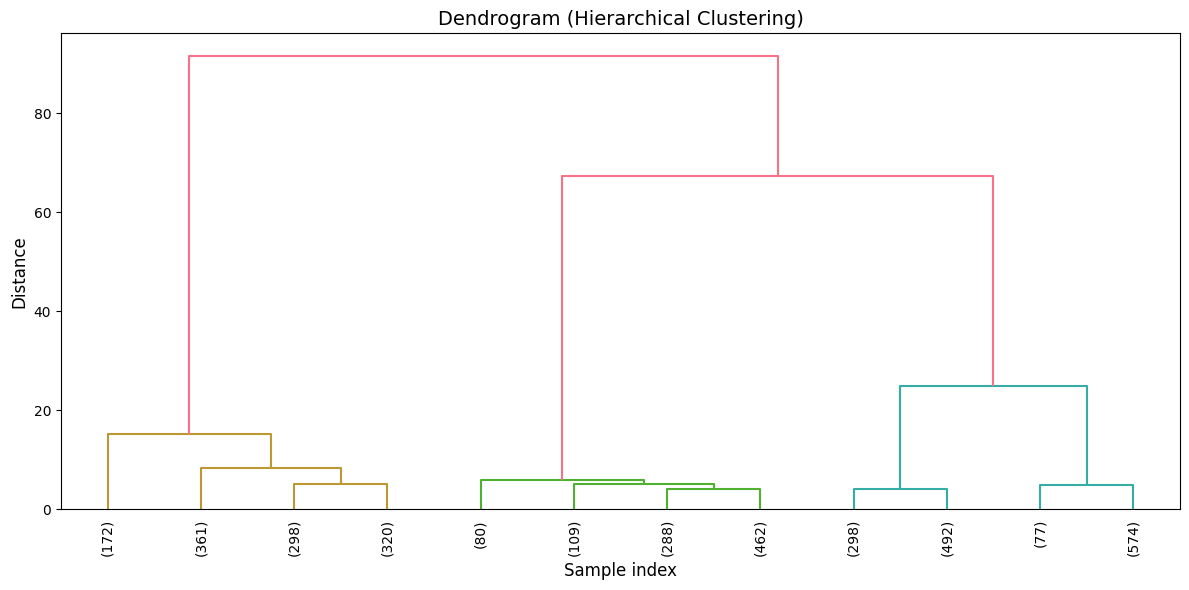

In [65]:
from sklearn.cluster import AgglomerativeClustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[[" Merchant ID", " Cluster ID"]])

# Списки для метрик
silhouette_scores = []
ari_scores = []
n_clusters_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]


for n in n_clusters_list:
    # Иерархическая кластеризация
    clusterer = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = clusterer.fit_predict(X_scaled)

    # Метрики
    sil = metrics.silhouette_score(X_scaled, labels)
    ari = metrics.adjusted_rand_score(y, labels)

    silhouette_scores.append(sil)
    ari_scores.append(ari)

    print(f"n={n}: Silhouette={sil:.4f}, ARI={ari:.4f}")

# График
plt.figure(figsize=(10, 6))
plt.plot(n_clusters_list, silhouette_scores, 'bo-', linewidth=2, markersize=8, label='Silhouette Score')
plt.plot(n_clusters_list, ari_scores, 'rs-', linewidth=2, markersize=8, label='Adjusted Rand Index')

# Лучшие точки
best_sil_idx = silhouette_scores.index(max(silhouette_scores))
best_ari_idx = ari_scores.index(max(ari_scores))

plt.scatter(n_clusters_list[best_sil_idx], silhouette_scores[best_sil_idx],
           color='green', s=200, marker='*', zorder=5,
           label=f'Best Silhouette: n={n_clusters_list[best_sil_idx]} ({silhouette_scores[best_sil_idx]:.3f})')
plt.scatter(n_clusters_list[best_ari_idx], ari_scores[best_ari_idx],
           color='orange', s=200, marker='*', zorder=5,
           label=f'Best ARI: n={n_clusters_list[best_ari_idx]} ({ari_scores[best_ari_idx]:.3f})')

plt.xlabel('Number of clusters', size=12)
plt.ylabel('Score', size=12)
plt.xticks(n_clusters_list)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.title('Hierarchical Clustering Performance', size=14)
plt.tight_layout()
plt.show()

# Дендрограмма (опционально)
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=12, leaf_rotation=90., leaf_font_size=10.)
plt.title('Dendrogram (Hierarchical Clustering)', size=14)
plt.xlabel('Sample index', size=12)
plt.ylabel('Distance', size=12)
plt.tight_layout()
plt.show()

иерархическая получилась лучше, результаты на нормализованных данных приемлемые. лучшее качество кластеризации достигнуто при разбиении на 4 кластера – значение силуэта составило 0.7708, что говорит о высокой компактности и хорошей разделимости кластеров

DBSCAN

In [68]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [69]:
# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[[" Merchant ID", " Cluster ID"]])

# Подбор параметров DBSCAN
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [5, 10, 12, 15]

best_silhouette = -1
best_params = {}

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        # Количество кластеров (исключая шум)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Силуэт считаем только если есть хотя бы 2 кластера и не все объекты в шуме
        if n_clusters >= 2 and n_noise < len(X_scaled) - 1:
            sil = metrics.silhouette_score(X_scaled, labels)
            print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шума={n_noise}, силуэт={sil:.3f}")

            if sil > best_silhouette:
                best_silhouette = sil
                best_params = {'eps': eps, 'min_samples': min_samples}
        else:
            print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шума={n_noise} → силуэт не считается")

print(f"\nЛучшие параметры: eps={best_params['eps']}, min_samples={best_params['min_samples']}")
print(f"Лучший силуэт: {best_silhouette:.3f}")

# Запускаем DBSCAN с лучшими параметрами
db_best = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
labels_best = db_best.fit_predict(X_scaled)

n_clusters = len(set(labels_best)) - (1 if -1 in labels_best else 0)
n_noise = list(labels_best).count(-1)

print(f"\nИтог: {n_clusters} кластеров, {n_noise} точек шума")

eps=0.3, min_samples=5: кластеров=3, шума=0, силуэт=0.754
eps=0.3, min_samples=10: кластеров=3, шума=0, силуэт=0.754
eps=0.3, min_samples=12: кластеров=3, шума=0, силуэт=0.754
eps=0.3, min_samples=15: кластеров=3, шума=0, силуэт=0.754
eps=0.5, min_samples=5: кластеров=2, шума=0, силуэт=0.608
eps=0.5, min_samples=10: кластеров=2, шума=0, силуэт=0.608
eps=0.5, min_samples=12: кластеров=2, шума=0, силуэт=0.608
eps=0.5, min_samples=15: кластеров=2, шума=0, силуэт=0.608
eps=0.7, min_samples=5: кластеров=2, шума=0, силуэт=0.608
eps=0.7, min_samples=10: кластеров=2, шума=0, силуэт=0.608
eps=0.7, min_samples=12: кластеров=2, шума=0, силуэт=0.608
eps=0.7, min_samples=15: кластеров=2, шума=0, силуэт=0.608
eps=1.0, min_samples=5: кластеров=2, шума=0, силуэт=0.608
eps=1.0, min_samples=10: кластеров=2, шума=0, силуэт=0.608
eps=1.0, min_samples=12: кластеров=2, шума=0, силуэт=0.608
eps=1.0, min_samples=15: кластеров=2, шума=0, силуэт=0.608

Лучшие параметры: eps=0.3, min_samples=5
Лучший силуэт: 0.7

что ж, результат предыдущих моделей подтвердился, правда, кластеров теперь 3, может быть 4 кластер менее плотный или граничный

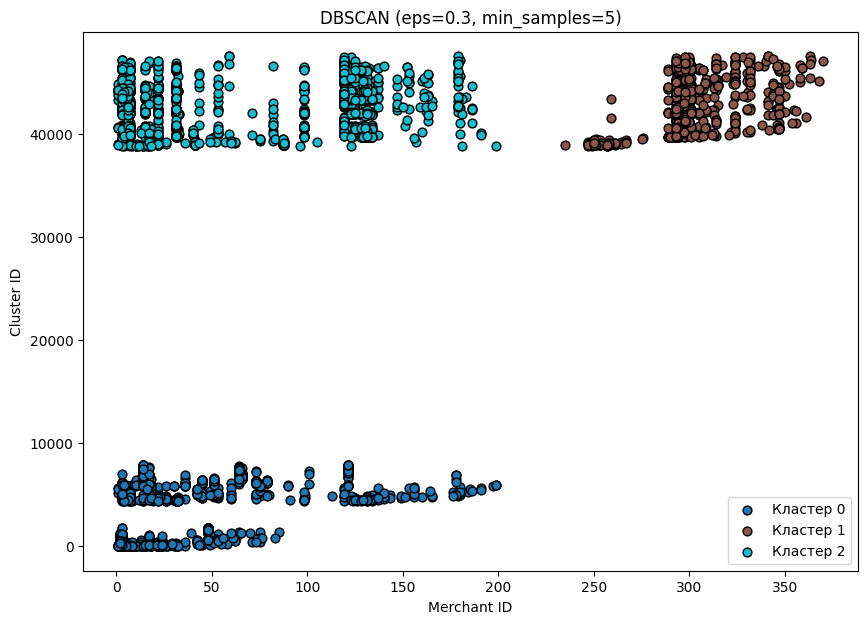

In [70]:
# Исправленный код визуализации для DBSCAN
core_samples_mask = np.zeros_like(labels_best, dtype=bool)
core_samples_mask[db_best.core_sample_indices_] = True

# Цвета для кластеров (включая шум)
unique_labels = set(labels_best)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(10, 7))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Шум — чёрный
        col = 'k'
        label = 'Шум'
    else:
        label = f'Кластер {k}'

    class_member_mask = (labels_best == k)

    # Ядерные точки
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[" Merchant ID"], xy[" Cluster ID"],
                c=[col], marker='o', s=40, edgecolor='k', label=label)

    # Периферийные точки
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[" Merchant ID"], xy[" Cluster ID"],
                c=[col], marker='o', s=20, alpha=0.6)

plt.xlabel("Merchant ID")
plt.ylabel("Cluster ID")
plt.title(f"DBSCAN (eps={best_params['eps']}, min_samples={best_params['min_samples']})")
plt.legend()
plt.show()

ну на группы разделил - и слава богу